# Auditing CROCUS data from ESS-DIVE

**ESS-DIVE** — the Environmental System Science Data Infrastructure for a Virtual
Ecosystem — is a U.S. Department of Energy repository for Earth and environmental science
data. The **CROCUS** project (Community Research on Climate and Urban Science) publishes
a sample of its urban sensor-network data there.

## What this notebook is (and its companion)

This repository handles CROCUS's ESS-DIVE data in two notebooks:

- **`build_essdive_archive.ipynb`** *(the companion)* — finds the CROCUS datasets on
  ESS-DIVE, downloads their daily NetCDF files into `data/essdive/tmp/<label>/`, and
  stitches each site/instrument's daily files into a single archive in
  `data/essdive/` (e.g. `NEIU_wxt_essdive.nc`). Run that notebook first; it produces the
  files this one reads.
- **`audit_essdive.ipynb`** *(this notebook)* — **assesses** those files. It does not
  download or build anything. It answers two questions:
  1. **Is the metadata correct?** Are units, `standard_name`, and value ranges present
     and physically sensible — or are there defects (e.g. a wind speed mislabeled as
     `celsius`)?
  2. **How much data do we actually have?** A coverage visualization shows, per site and
     instrument, which time periods are present and which are missing.

You can run this notebook without having read the companion: as long as the files exist
under `data/essdive/`, everything here works. If those files are missing, run
`build_essdive_archive.ipynb` first.

NetCDF is a common scientific format for array-oriented data (time series, gridded
fields, model output). In Python, `xarray` opens NetCDF files as labeled datasets, which
is what we use throughout.


In [ ]:
import json
import os
from datetime import datetime, timezone

import pandas as pd
import requests
import xarray as xr

In [2]:
ARCHIVEDIR  = "data/essdive"     
WORKDIR = "data/essdive/tmp"        # disposable daily chunks
      
os.makedirs(ARCHIVEDIR, exist_ok=True)
os.makedirs(WORKDIR, exist_ok=True)

## Why metadata matters, and what ESS-DIVE expects

A NetCDF file is only as useful as its metadata. A column of numbers labeled
`wind_mean_10s` is ambiguous until the file states its **units**, a **standard name**
that says what physical quantity it is, and enough provenance to know where it came from.
When metadata is missing or wrong, downstream users silently misinterpret the data —
plotting wind speed as if it were temperature, or mixing pressure in hPa with pressure in
Pa.

ESS-DIVE publishes reporting-format guidance for exactly this reason. For gridded/array
environmental data the relevant expectations draw on the **CF (Climate and Forecast)
conventions**, which most of the community follows. In practice, a well-formed CROCUS
variable should carry:

- **`units`** — a CF-style unit string (e.g. `m s-1` for wind speed, `degree_Celsius`
  for temperature, `hPa` for pressure, `percent` for relative humidity). The string must
  match the physical quantity.
- **`standard_name`** — a controlled CF vocabulary term (e.g. `wind_speed`,
  `air_temperature`, `air_pressure`, `relative_humidity`, `wind_from_direction`) so that
  software can identify the quantity unambiguously. Where no CF standard name exists, a
  descriptive **`long_name`** should be present instead.
- **coherent value ranges** — the actual data should fall within physically plausible
  bounds for the declared quantity (a `relative_humidity` outside 0–100 %, or a
  `wind_speed` reported in `celsius`, is a red flag).
- **file-level provenance** — `Conventions` (e.g. `CF-1.x`), title, source instrument,
  site, and creation/processing history, so the file is self-describing and citable.

The checks below encode a practical subset of these expectations: presence of
`units`/`standard_name`, physical plausibility of units given the standard name, and
value-range sanity. They are intentionally conservative — they flag the specific defects
seen in the CROCUS WXT files (wind variables mislabeled `celsius`, a derived variable
with no units, rainfall with no accumulation-vs-rate semantics) without trying to be a
full CF compliance checker.

**References.** The authoritative specification is the
[CF (Climate and Forecast) conventions](https://cfconventions.org/Data/cf-conventions/cf-conventions-1.13/cf-conventions.html)
(version 1.13). The controlled vocabulary of valid `standard_name` values — the terms a
variable's `standard_name` attribute should be drawn from — is the
[CF standard name table](https://cfconventions.org/Data/cf-standard-names/current/build/cf-standard-name-table.html).
ESS-DIVE's own reporting-format guidance builds on these conventions.


## 1. Open and inspect a finished archive

Open a built archive and look at what's inside — variables, time range, and any
provenance attributes. Change the filename to inspect a different site/instrument.

In [3]:
ds = xr.open_dataset(os.path.join(ARCHIVEDIR, "NEIU_wxt_essdive.nc"))
ds

/home/anderson/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 64MB
Dimensions:        (time: 797641)
Coordinates:
  * time           (time) datetime64[ns] 6MB 2023-05-16T21:30:10 ... 2023-08-...
Data variables:
    temperature    (time) float64 6MB ...
    humidity       (time) float64 6MB ...
    pressure       (time) float64 6MB ...
    rainfall       (time) float64 6MB ...
    dewpoint       (time) float64 6MB ...
    wetbulb        (time) float64 6MB ...
    wind_dir_10s   (time) float64 6MB ...
    wind_mean_10s  (time) float64 6MB ...
    wind_max_10s   (time) float64 6MB ...
Attributes:
    conventions:        CF 1.10
    site_ID:            NEIU
    node:               W08D
    CAMS_tag:           CMS-WXT-002
    datastream:         CMS_wxt536_NEIU_a1
    datalevel:          a1
    latitude:           41.9804526
    longitude:          -87.7196038
    source_archive:     ESS-DIVE ess-dive-b43a0b35cacbef1-20240501T175506250
    source_url:         https://data.ess-dive.lbl.gov/view/doi:10.15485/2338027
    essdive_retrieved:  2026-06-27T14:09:52.626602+00:00
    essdive_n_files:    97

## 2. Metadata sanity check (one archive)

Whether or not a variable *has* a `units` string, that string can still be wrong. This
check cross-examines each variable three ways: does it carry `units` and `standard_name`
at all; do the units make physical sense for the declared `standard_name` (a
`wind_speed` must not be in `celsius`); and do the actual data ranges look consistent
with those units. It flags the specific defects seen in the CROCUS WXT archive.

In [4]:
import numpy as np

# Physical sanity: which units are plausible for a given CF standard_name.
# Keyed by standard_name; value is a set of acceptable unit strings (lowercased).
_PLAUSIBLE = {
    "air_temperature":       {"celsius", "degc", "k", "kelvin"},
    "dew_point_temperature": {"celsius", "degc", "k", "kelvin"},
    "relative_humidity":     {"percent", "%", "1"},
    "air_pressure":          {"hpa", "pa", "mbar", "mb"},
    "wind_speed":            {"m s-1", "m/s", "meters per second"},
    "wind_from_direction":   {"degree", "degrees", "degree_true"},
    "precipitation_amount":  {"kg m-2", "mm"},
}

# Rough physical range each standard_name should fall in (after unit interpretation).
_RANGE = {
    "air_temperature":       (-60, 60),
    "dew_point_temperature": (-60, 50),
    "relative_humidity":     (0, 100),
    "air_pressure":          (800, 1100),   # hPa
    "wind_speed":            (0, 120),       # m/s
    "wind_from_direction":   (0, 360),
}


def check_metadata(path):
    """Report per-variable metadata quality and flag likely defects."""
    ds = xr.open_dataset(path)
    print(f"== {path} ==")
    print(f"   conventions: {ds.attrs.get('conventions', '(none)')}")
    print(f"   {len(ds.data_vars)} data variables, "
          f"{ds.sizes.get('time', '?')} time steps\n")

    problems = []
    header = f"   {'variable':16s} {'units':12s} {'standard_name':24s} status"
    print(header)
    print("   " + "-" * (len(header) - 3))

    for name in ds.data_vars:
        da = ds[name]
        units = da.attrs.get("units")
        sname = da.attrs.get("standard_name")
        flags = []

        if units is None:
            flags.append("NO UNITS")
        if sname is None and "long_name" not in da.attrs:
            flags.append("no standard_name/long_name")

        # units-vs-standard_name plausibility
        if sname and units is not None:
            ok = _PLAUSIBLE.get(sname)
            if ok and units.strip().lower() not in ok:
                flags.append(f"UNITS '{units}' inconsistent with '{sname}'")

        # data-range plausibility against the standard_name
        if sname in _RANGE:
            vals = np.asarray(da.values, dtype="float64")
            vals = vals[np.isfinite(vals)]
            if vals.size:
                lo, hi = _RANGE[sname]
                if vals.min() < lo or vals.max() > hi:
                    flags.append(
                        f"range [{vals.min():.1f}, {vals.max():.1f}] "
                        f"outside expected [{lo}, {hi}]")

        # accumulation/rate ambiguity for precipitation
        if sname == "precipitation_amount" and "long_name" not in da.attrs:
            flags.append("no long_name: accumulation vs rate unstated")

        status = "OK" if not flags else "  ||  ".join(flags)
        print(f"   {name:16s} {str(units):12.12s} {str(sname):24.24s} {status}")
        if flags:
            problems.append((name, flags))

    print()
    if problems:
        print(f"   {len(problems)} variable(s) with metadata issues:")
        for name, flags in problems:
            for f in flags:
                print(f"     - {name}: {f}")
    else:
        print("   no metadata issues detected.")
    ds.close()
    return problems


# Run it on the finished archive (and works on raw per-file downloads too).
_ = check_metadata(os.path.join(ARCHIVEDIR, "NEIU_wxt_essdive.nc"))


== data/essdive/NEIU_wxt_essdive.nc ==
   conventions: CF 1.10
   9 data variables, 797641 time steps

   variable         units        standard_name            status
   -------------------------------------------------------------
   temperature      None         None                     NO UNITS  ||  no standard_name/long_name
   humidity         None         None                     NO UNITS  ||  no standard_name/long_name
   pressure         None         None                     NO UNITS  ||  no standard_name/long_name
   rainfall         None         None                     NO UNITS  ||  no standard_name/long_name
   dewpoint         None         None                     NO UNITS  ||  no standard_name/long_name
   wetbulb          None         None                     NO UNITS  ||  no standard_name/long_name
   wind_dir_10s     None         None                     NO UNITS  ||  no standard_name/long_name
   wind_mean_10s    None         None                     NO UNITS  ||  no

## 3. Network-wide metadata audit (raw source files)

Section 2 checks one *finished* archive. This section inspects the **raw per-file
downloads** in `data/essdive/tmp/<label>/` — the files exactly as ESS-DIVE published
them, before any concatenation of ours. It answers a different question: *what metadata
defects exist in the source data, and are they network-wide or specific to one site?*

For each download folder it runs the same per-variable checks across every file,
**aggregates** each defect with a count (e.g. `wind_mean_10s units='celsius' — 97/97
files`), and flags **intra-site inconsistency** — cases where files in the *same* folder
disagree on a variable's attributes (the inconsistency that caused attribute loss in our
own concatenation). It is read-only and safe to re-run as more sites are downloaded.

In [5]:
import glob
from collections import defaultdict


def _var_signature(da):
    """A hashable summary of one variable's metadata, for spotting files that
    disagree. (units, standard_name, has_long_name)."""
    return (da.attrs.get("units"),
            da.attrs.get("standard_name"),
            "long_name" in da.attrs)


def _defects_for_var(name, da, vals_minmax):
    """Return a list of defect strings for one variable (no data load here;
    ranges are passed in)."""
    units = da.attrs.get("units")
    sname = da.attrs.get("standard_name")
    flags = []
    if units is None:
        flags.append("no units")
    if sname is None and "long_name" not in da.attrs:
        flags.append("no standard_name/long_name")
    if sname and units is not None:
        ok = _PLAUSIBLE.get(sname)
        if ok and units.strip().lower() not in ok:
            flags.append(f"units '{units}' inconsistent with '{sname}'")
    if sname == "precipitation_amount" and "long_name" not in da.attrs:
        flags.append("rainfall: accumulation vs rate unstated")
    if sname in _RANGE and vals_minmax is not None:
        lo, hi = _RANGE[sname]
        vmin, vmax = vals_minmax
        if vmin < lo or vmax > hi:
            flags.append(f"data range [{vmin:.1f}, {vmax:.1f}] outside [{lo}, {hi}]")
    return flags


def audit_site(folder, check_ranges=True):
    """Audit every .nc file in one raw download folder. Aggregates defects with
    counts and flags intra-site attribute inconsistency."""
    files = sorted(glob.glob(os.path.join(folder, "*.nc")))
    label = os.path.basename(folder.rstrip("/"))
    if not files:
        print(f"[{label}] no .nc files")
        return None

    n = len(files)
    defect_counts = defaultdict(int)            # (var, defect) -> count of files
    signatures = defaultdict(set)               # var -> set of metadata signatures
    var_seen = defaultdict(int)                 # var -> count of files containing it

    for path in files:
        ds = xr.open_dataset(path)
        for name in ds.data_vars:
            da = ds[name]
            var_seen[name] += 1
            signatures[name].add(_var_signature(da))
            vmm = None
            if check_ranges and da.attrs.get("standard_name") in _RANGE:
                v = np.asarray(da.values, dtype="float64")
                v = v[np.isfinite(v)]
                if v.size:
                    vmm = (float(v.min()), float(v.max()))
            for flag in _defects_for_var(name, da, vmm):
                defect_counts[(name, flag)] += 1
        ds.close()

    print(f"== {label}: {n} file(s) ==")

    # Aggregated defects
    if defect_counts:
        print("  defects (count / files containing the variable):")
        for (var, flag), c in sorted(defect_counts.items()):
            print(f"    {var:16s} {flag:48s} {c}/{var_seen[var]}")
    else:
        print("  no defects detected.")

    # Intra-site inconsistency: a variable whose metadata signature is not the
    # same in every file that contains it.
    inconsistent = {v: sigs for v, sigs in signatures.items() if len(sigs) > 1}
    if inconsistent:
        print("  INTRA-SITE INCONSISTENCY (files disagree on these variables' metadata):")
        for v, sigs in sorted(inconsistent.items()):
            print(f"    {v}: {len(sigs)} distinct (units, standard_name, has_long_name) signatures")
            for s in sorted(sigs, key=lambda x: tuple("" if e is None else str(e) for e in x)):
                print(f"        units={s[0]!r}, standard_name={s[1]!r}, long_name={s[2]}")
    print()
    return {"label": label, "n_files": n,
            "defects": dict(defect_counts), "inconsistent": inconsistent}


def audit_all(tmp_root=WORKDIR, check_ranges=True):
    """Audit every site folder under the raw-download root."""
    folders = sorted(p for p in glob.glob(os.path.join(tmp_root, "*"))
                     if os.path.isdir(p))
    if not folders:
        print(f"no site folders under {tmp_root!r} — download something first.")
        return []
    print(f"Auditing {len(folders)} site folder(s) under {tmp_root!r}\n")
    return [audit_site(f, check_ranges=check_ranges) for f in folders]


# Run across everything downloaded so far.
_audit = audit_all()


Auditing 9 site folder(s) under 'data/essdive/tmp'

== ANL_aqt: 57 file(s) ==
  no defects detected.

== ANL_wxt: 69 file(s) ==
  defects (count / files containing the variable):
    rainfall         rainfall: accumulation vs rate unstated          69/69
    wetbulb          no standard_name/long_name                       69/69
    wetbulb          no units                                         69/69
    wind_max_10s     units 'celsius' inconsistent with 'wind_speed'   69/69
    wind_mean_10s    units 'celsius' inconsistent with 'wind_speed'   69/69

== CSU_aqt: 156 file(s) ==
  no defects detected.

== CSU_wxt: 53 file(s) ==
  defects (count / files containing the variable):
    rainfall         rainfall: accumulation vs rate unstated          53/53
    wetbulb          no standard_name/long_name                       53/53
    wetbulb          no units                                         53/53
    wind_max_10s     units 'celsius' inconsistent with 'wind_speed'   53/53
    wind

## 4. Data coverage

Metadata quality is one axis of an audit; **how much data actually exists** is the other.
A file can be perfectly well-formed and still cover only a few scattered weeks. This
section builds a coverage picture of the finished archives in `data/essdive/`.

For each archive we bin the time axis by month and measure how full each month is — the
fraction of expected time steps actually present. (The expected count comes from the
archive's own median sampling step, so it adapts to 10-second WXT files and 60-second AQT
files without hard-coding either.) The result is a **site × month heatmap**: bright cells
are well-covered months, dim cells are sparse, blank cells are missing entirely.

In [6]:
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

def coverage_table(archive_dir=ARCHIVEDIR, pattern="*_essdive.nc"):
    """DataFrame: rows = archives, cols = months (MS), values = coverage fraction.

    Coverage fraction = (actual samples in month) / (expected samples in month),
    where expected = seconds_in_month / median_sampling_step. Adapts automatically
    to each file's cadence (10 s WXT, 60 s AQT)."""
    files = sorted(glob.glob(os.path.join(archive_dir, pattern)))
    series = {}
    for f in files:
        label = os.path.basename(f).replace("_essdive.nc", "")
        ds = xr.open_dataset(f)
        t = pd.to_datetime(ds["time"].values)
        ds.close()
        if len(t) < 3:
            continue
        step_s = float(np.median(np.diff(t).astype("timedelta64[s]").astype(float)))
        if step_s <= 0:
            continue
        counts = pd.Series(1, index=t).resample("MS").count()
        secs_in_month = counts.index.to_series().apply(
            lambda d: ((d + pd.offsets.MonthBegin(1)) - d).total_seconds())
        frac = counts.values / (secs_in_month.values / step_s)
        series[label] = pd.Series(frac, index=counts.index)
    if not series:
        return pd.DataFrame()
    df = pd.DataFrame(series).T
    return df.reindex(sorted(df.columns), axis=1)

cov = coverage_table()
cov if cov.empty else cov.round(2)


,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01
ANL_aqt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.91,0.64,0.02,0.05
ANL_wxt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.31,0.69,0.94,0.05
CSU_aqt,NaN,NaN,NaN,NaN,NaN,0.46,0.93,0.78,0.97,1.0,0.69,NaN,NaN,NaN,NaN,NaN
CSU_wxt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.27,0.53,0.81,0.02
NEIU_aqt,0.32,1.0,0.51,0.98,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NEIU_wxt,0.42,0.9,0.72,0.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NU_wxt,NaN,NaN,NaN,NaN,NaN,0.45,0.81,0.90,0.87,0.9,0.90,0.69,0.65,0.93,0.96,0.02
UIC_aqt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.18,0.92,0.61,0.02,NaN
UIC_wxt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.16,0.48,0.69,0.91,0.11


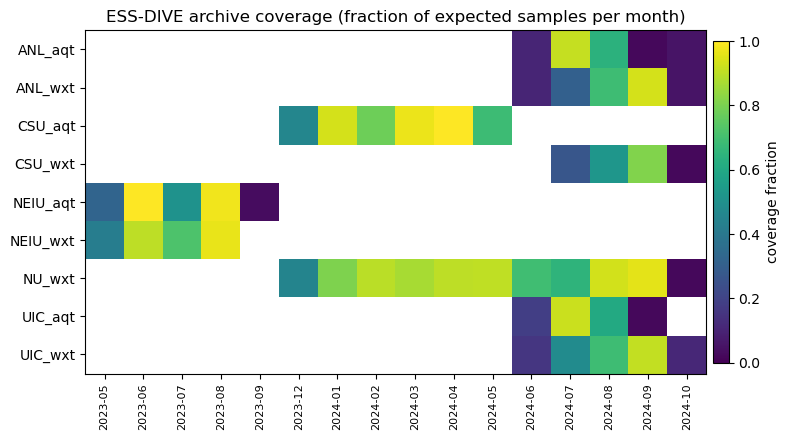

In [7]:
# Heatmap of the coverage table
if cov.empty:
    print("No archives found in", ARCHIVEDIR, "- run build_essdive_archive.ipynb first.")
else:
    fig, ax = plt.subplots(figsize=(max(8, 0.28 * cov.shape[1]),
                                    max(3, 0.5 * cov.shape[0])))
    im = ax.imshow(cov.values, aspect="auto", cmap="viridis",
                   vmin=0, vmax=1, interpolation="nearest")

    ax.set_yticks(range(cov.shape[0]))
    ax.set_yticklabels(cov.index)

    months = [c.strftime("%Y-%m") for c in cov.columns]
    step = max(1, len(months) // 24)          # label at most ~24 months
    ax.set_xticks(range(0, len(months), step))
    ax.set_xticklabels(months[::step], rotation=90, fontsize=8)

    ax.set_title("ESS-DIVE archive coverage (fraction of expected samples per month)")
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
    cbar.set_label("coverage fraction")
    plt.tight_layout()
    plt.show()


### Coverage vs. the intended network

The heatmap above shows only the site/instrument archives that actually reached
ESS-DIVE. This second version instead shows the **full intended network** — every
site's WXT and AQT — so that combinations which reported *nothing* are visible too,
and deployment dates from `crocus_sites.py` distinguish "not yet installed" from a real
data gap.

Reading it:

- **grey** — the instrument was not deployed that month: either before its install date,
  or never deployed at that site at all (for example, IBP was slated for a WXT and AQT
  that were never installed, so those rows are entirely grey).
- **colour** — deployed and reporting, shaded by coverage fraction.
- **white inside a coloured span** — deployed but no data that month: a genuine gap, and
  in the ESS-DIVE context, data still to be submitted.

So grey is "not applicable / didn't happen," colour is "delivered," and white-within-
colour is "outstanding." Rows whose site or instrument cannot be matched to the registry
are shown without a deployment overlay.

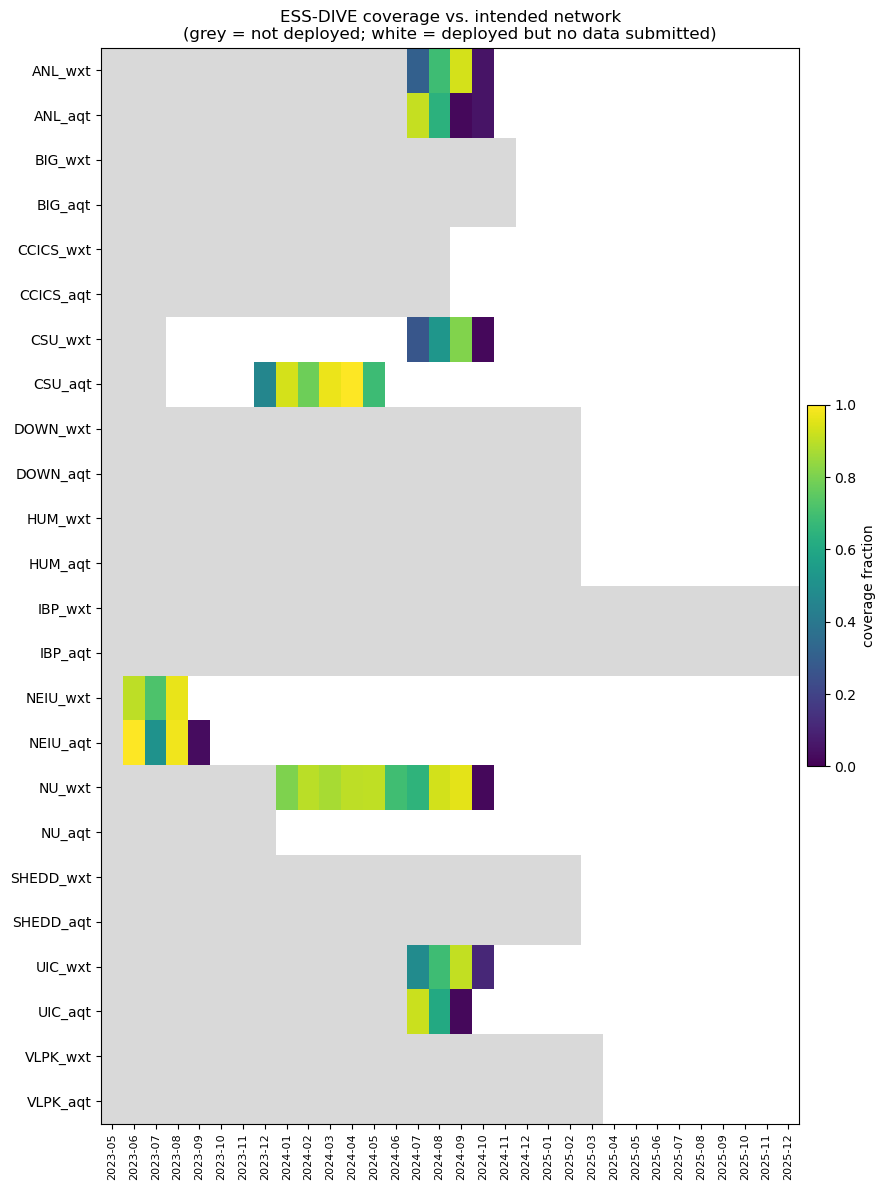

In [9]:
# Deployment-aware coverage heatmap (Option B: full intended network).
# Rows = EVERY site's wxt and aqt from the registry, not only those that reported
# to ESS-DIVE. Combined with the deployment overlay this shows the whole intended
# network and how much of it has been delivered:
#   grey   = instrument not deployed that month (pre-install, or never deployed here,
#            e.g. IBP's planned-but-never-installed wxt/aqt);
#   colour = deployed and reported, shaded by coverage fraction;
#   white  = deployed but no data that month  -> a genuine gap / still to submit.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import crocus_sites as cs

# Archives label the Argonne site "ANL"; the registry calls it "ATMOS".
REG_TO_ARCHIVE = {"ATMOS": "ANL"}                 # registry abbr -> archive row label
ARCHIVE_TO_REG = {v: k for k, v in REG_TO_ARCHIVE.items()}
SITE_BY_ABBR = {s.abbr: s for s in cs.ALL_SITES}

def _lookup_site(row_site):
    """Row-label site string -> registry site object (handles ANL/ATMOS alias)."""
    return SITE_BY_ABBR.get(ARCHIVE_TO_REG.get(row_site, row_site))

def _parse_row(label):
    parts = label.split("_")
    return (parts[0], parts[1].lower()) if len(parts) >= 2 else (label, None)

if cov.empty:
    print("No archives found in", ARCHIVEDIR, "- run build_essdive_archive.ipynb first.")
else:
    # ---- Option B: expected rows = every site's wxt and aqt (intended network) ----
    expected_rows = []
    for s in cs.ALL_SITES:
        label_site = REG_TO_ARCHIVE.get(s.abbr, s.abbr)   # use archive label (ANL)
        for instr in ("wxt", "aqt"):
            expected_rows.append(f"{label_site}_{instr}")
    # keep any existing rows too (in case an archive exists we didn't anticipate),
    # then order: expected first (registry order), then extras.
    extra = [r for r in cov.index if r not in expected_rows]
    all_rows = expected_rows + extra
    covB = cov.reindex(index=all_rows)                    # missing rows -> all NaN

    # Extend the month axis out to end of 2025 so later deployments are visible
    full_months = pd.date_range(covB.columns.min(), "2025-12-01", freq="MS")
    covB = covB.reindex(columns=full_months)          # new months -> all NaN

    # ---- deployment mask aligned to covB ----
    not_deployed = np.zeros(covB.shape, dtype=bool)
    for r, label in enumerate(covB.index):
        site_str, instr = _parse_row(label)
        site = _lookup_site(site_str)
        if site is None or instr is None:
            continue
        for c, month in enumerate(covB.columns):
            if site.deployed(instr, month) is False:      # pre-install OR never here
                not_deployed[r, c] = True

    fig, ax = plt.subplots(figsize=(max(8, 0.28 * covB.shape[1]),
                                    max(3, 0.5 * covB.shape[0])))
    im = ax.imshow(covB.values, aspect="auto", cmap="viridis",
                   vmin=0, vmax=1, interpolation="nearest")
    grey = np.ma.masked_where(~not_deployed, np.ones_like(covB.values))
    ax.imshow(grey, aspect="auto", interpolation="nearest",
              cmap=mcolors.ListedColormap(["#d9d9d9"]), vmin=0, vmax=1)

    ax.set_yticks(range(covB.shape[0]))
    ax.set_yticklabels(covB.index)
    months = [c.strftime("%Y-%m") for c in covB.columns]
    step = max(1, len(months) // 24)
    ax.set_xticks(range(0, len(months), step))
    ax.set_xticklabels(months[::step], rotation=90, fontsize=8)

    ax.set_title("ESS-DIVE coverage vs. intended network\n"
                 "(grey = not deployed; white = deployed but no data submitted)")
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
    cbar.set_label("coverage fraction")
    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    fig.savefig("figures/essdive_coverage_deployment.png", dpi=150, bbox_inches="tight")
    plt.show()

**Reading the heatmap.** Each row is one site/instrument archive; each column is a
month. Brightness is the fraction of expected time steps present that month: bright ≈
complete, dim = partial, blank/dark = no data. Because the expected sample count is
derived from each file's own sampling step, WXT (10-second) and AQT (60-second) archives
share the same 0–1 scale. Fractions slightly above 1 can occur where the true cadence is
marginally faster than the median step (the CROCUS WXT stream runs a little above its
nominal rate); the colour scale clips at 1.

Sparse or missing months are the point of this view: they show at a glance where the
published ESS-DIVE sample actually has data and where it does not — the kind of coverage
gap that is easy to overlook when inspecting one file at a time.

## Notes and next steps

- **This notebook is read-only.** It inspects files; it does not modify or re-publish
  them. Metadata defects found here (e.g. wind variables labeled `celsius`) are defects
  in the *published* ESS-DIVE files; correcting them would produce a clearly-labeled
  *derived* product (e.g. a `_qc` copy), not a replacement for the ESS-DIVE record.
- **Provenance of the wind mean.** A separate investigation
  (`reverse_engineer_essdive.ipynb`) found that the published `wind_mean_10s` could not
  be reproduced from the native high-rate wind samples by the standard aggregations
  tested, so its construction method is not yet established. Treat that variable with
  corresponding caution.
- **Scope.** Coverage and metadata results reflect whatever has been downloaded into
  `data/essdive/`; re-run after fetching additional sites or windows to update the view.
